In [1]:
import sys
sys.path.append("/Users/emilieyu/endotehelial-masboss") # replace with own folder for notebook imports

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

# Library imports
from src.config import load_abm_sim_cfg, load_abm_sweep_cfg
from src.paths import BM_RESULTS_DIR, ABM_SWEEP_RES_DIR, ABM_SWEEP_FIG_DIR
from abm.experiments.experiment_runner import ExperimentRunner
from abm.experiments.parameter_sweep import run_sweeps
from abm.plotting.sweep_plotter import *


# Looad sweeps and runner
sim_cfg = load_abm_sim_cfg()
sweep_cfg = load_abm_sweep_cfg()
runner = ExperimentRunner(sim_cfg, BM_RESULTS_DIR)

>>> DEBUG: Successfully loaded recruitment parameter sweep data.
>>> DEBUG: Successfully built interpolators
LUT ready | rest: RhoA=0.395 RhoC=0.406


## Run Contractility Competition Sweep

Runs 2D a_sf vs a_cortex sweep, returns a DataFrame, and stores results in results/abm_sweep. Full runtime is around 10 min. 

In [2]:
df = run_sweeps(runner=runner, sweep_cfg=sweep_cfg, 
                target_sweeps="contractility_competition", target_type=None, 
                result_dir=ABM_SWEEP_RES_DIR)


>>> INFO: Initialising sweep: contractility_competition (2D)
>>> INFO: Starting 2D sweep: contractility_competition
>>> INFO: 49 parameter combinations
    [1/49] {'cortex.a_drop': 0.0, 'stress_fibre.a_drop': 0.0}
>>> DEBUG: Successfully loaded recruitment parameter sweep data.
>>> DEBUG: Successfully built interpolators
LUT ready | rest: RhoA=0.395 RhoC=0.406
>>> INFO: Running perturbation: WT for 2000 steps.
 WT ar=1.763 | rho_balance=-0.004 | rhoa=0.468 | rhoc=0.464 | t=1.9s
>>> INFO: Running perturbation: DSP_KO for 2000 steps.
 DSP_KO ar=1.763 | rho_balance=0.193 | rhoa=0.331 | rhoc=0.524 | t=1.9s
>>> INFO: Running perturbation: TJP1_KO for 2000 steps.
 TJP1_KO ar=1.763 | rho_balance=-0.200 | rhoa=0.528 | rhoc=0.329 | t=2.0s
>>> INFO: Running perturbation: JCAD_KO for 2000 steps.
 JCAD_KO ar=1.763 | rho_balance=0.007 | rhoa=0.433 | rhoc=0.439 | t=1.7s
>>> INFO: Running perturbation: DSP_JCAD_DKO for 2000 steps.
 DSP_JCAD_DKO ar=1.763 | rho_balance=0.133 | rhoa=0.353 | rhoc=0.486 

In [6]:
df

,step,time,perturbation,cell_id,ar,area_ratio,perimeter,major,minor,t_load_polar,...,dsp_ratio,cortex_T_ratio,cortex_a_mean,sf_T,sf_a,sf_squeeze,sweep_name,type,cortex.a_drop,stress_fibre.a_drop
0,1999,199.9,WT,0,1.763,1.0017,79.314,31.236,17.717,8.067,...,647.999935,0.805009,0.950,8.2718,0.810,2.4815,contractility_competition,2D,0.0,0.0
1,1999,199.9,DSP_KO,0,1.763,1.0017,79.314,31.236,17.717,8.067,...,0.000000,0.805009,0.950,8.2718,0.810,2.4815,contractility_competition,2D,0.0,0.0
2,1999,199.9,TJP1_KO,0,1.763,1.0017,79.314,31.236,17.717,8.067,...,647.999935,0.805009,0.950,8.2718,0.810,2.4815,contractility_competition,2D,0.0,0.0
3,1999,199.9,JCAD_KO,0,1.763,1.0017,79.314,31.236,17.717,8.067,...,647.999935,0.805009,0.950,8.2718,0.810,2.4815,contractility_competition,2D,0.0,0.0
4,1999,199.9,DSP_JCAD_DKO,0,1.763,1.0017,79.314,31.236,17.717,8.067,...,0.000000,0.805009,0.950,8.2718,0.810,2.4815,contractility_competition,2D,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
289,1999,199.9,DSP_KO,0,1.471,1.0121,77.426,28.998,19.708,12.645,...,0.000000,0.818513,0.755,11.9644,0.488,3.5893,contractility_competition,2D,0.6,0.6
290,1999,199.9,TJP1_KO,0,1.135,1.0013,75.189,25.522,22.490,10.342,...,1.465784,0.936352,0.521,6.5936,0.674,1.9781,contractility_competition,2D,0.6,0.6
291,1999,199.9,JCAD_KO,0,1.273,1.0022,75.809,26.968,21.179,11.677,...,3.004505,0.886248,0.655,9.5621,0.557,2.8686,contractility_competition,2D,0.6,0.6
292,1999,199.9,DSP_JCAD_DKO,0,1.415,1.0141,77.112,28.504,20.143,12.152,...,0.000000,0.832509,0.740,11.1594,0.515,3.3478,contractility_competition,2D,0.6,0.6


## Contractility Competition Analysis

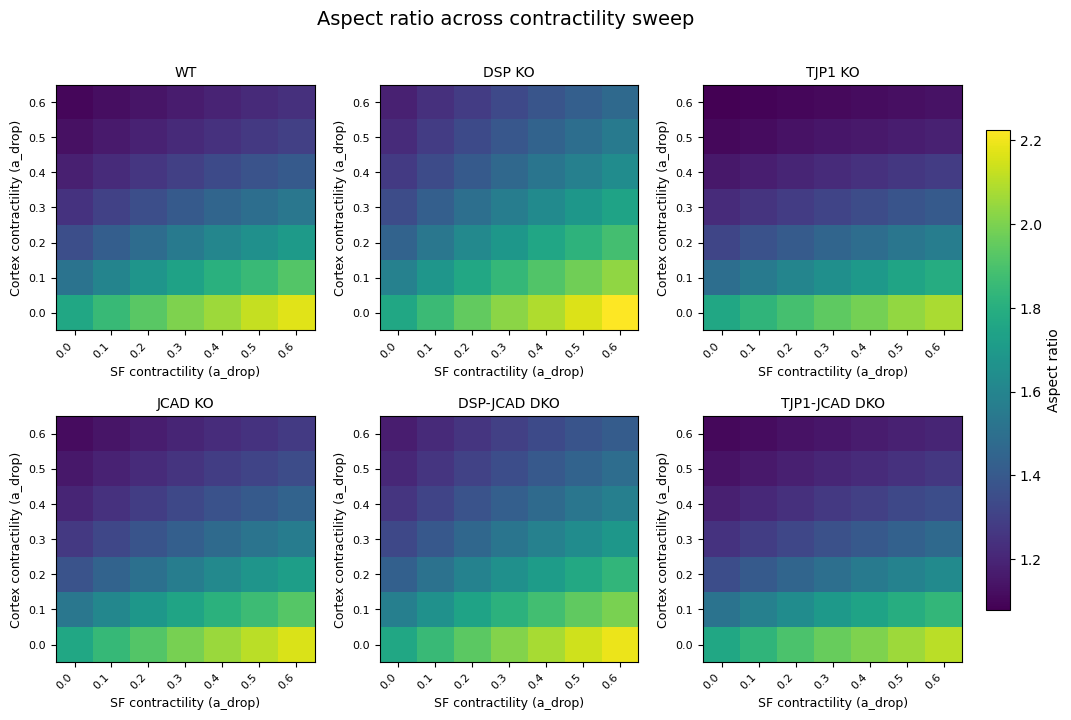

In [ ]:
plot_ar_heatmaps(df, ABM_SWEEP_FIG_DIR)

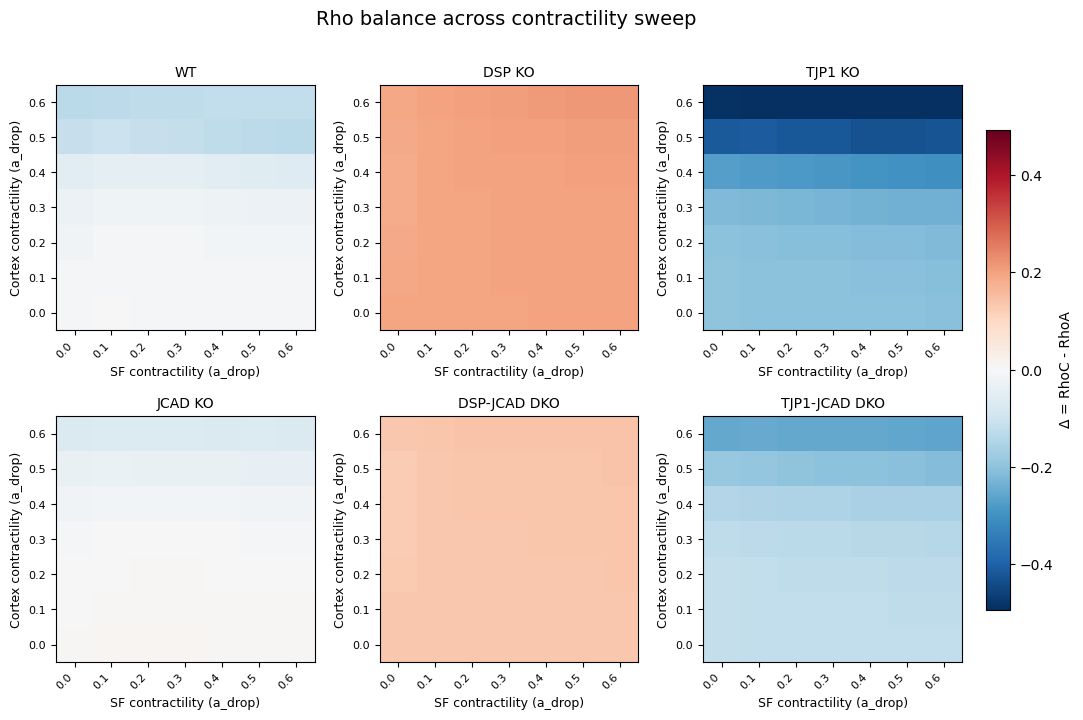

In [ ]:
plot_rho_balance_heatmaps(df, ABM_SWEEP_FIG_DIR)

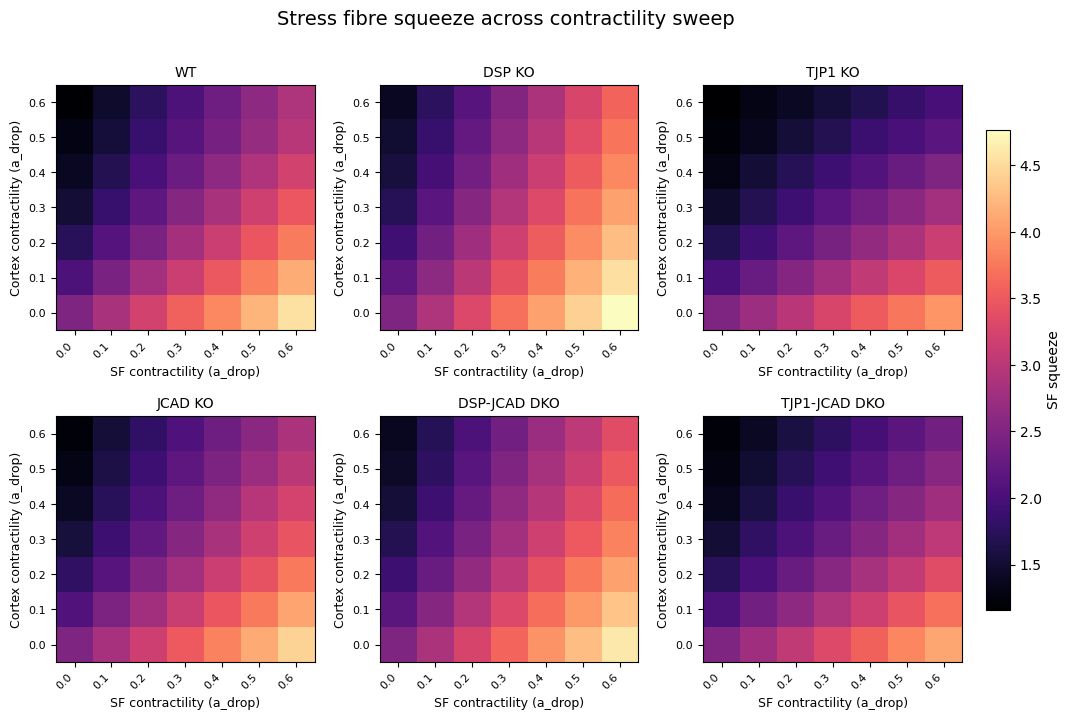

In [ ]:
plot_sf_squeeze_heatmaps(df, ABM_SWEEP_FIG_DIR)

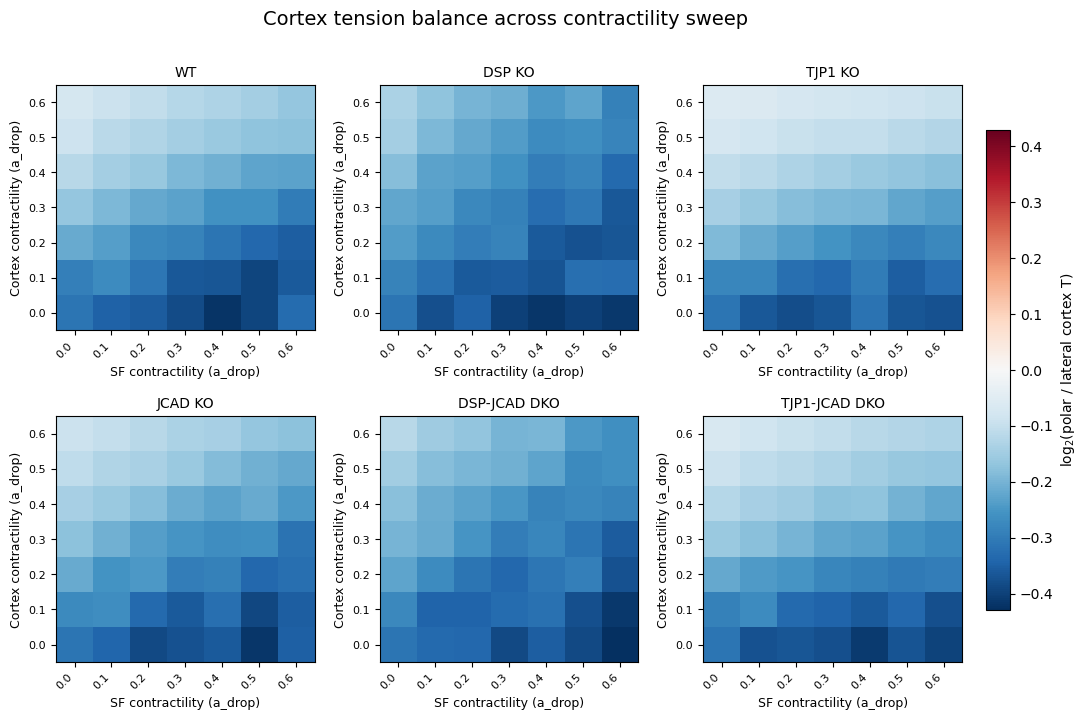

In [ ]:
plot_cortex_balance_heatmaps(df, ABM_SWEEP_FIG_DIR)